In [1]:
import pytearcat as pt
import itertools

Using the definition for the Scharzschild Metric in [Wikipedia](https://en.wikipedia.org/wiki/Schwarzschild_metric#Curvatures)

In [2]:
t,r,theta,phi = pt.coords('t,r,theta,phi')
rs = pt.con('rs') # rs = 2GM/c^2
c = pt.con('c')

g = pt.metric('ds2 = (1 - rs/r) * c**2 *dt**2 - 1/(1 - rs/r) * dr**2 - r**2 * (dtheta**2 + sin(theta)**2 * dphi**2)')

Remember that the time coordinate must be the first coordinate.

Dimension = 4
Coordinates = t,r,theta,phi
Metric defined successfully: 



<IPython.core.display.Math object>

Matrix([
[c**2 - c**2*rs/r,             0,     0,                   0],
[               0, -1/(1 - rs/r),     0,                   0],
[               0,             0, -r**2,                   0],
[               0,             0,     0, -r**2*sin(theta)**2]])

The Ricci curvature scalar and the Ricci curvature tensor are both zero. Non-zero components of the Riemann curvature tensor are[25]

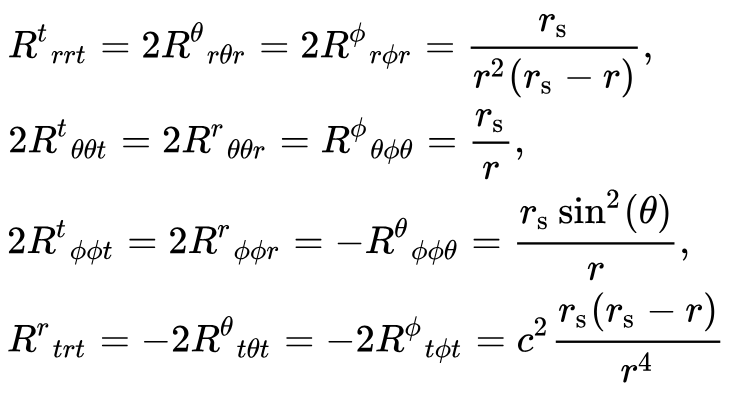

In [3]:
Ricci = pt.ricci()
Rscalar = pt.riccis()

<IPython.core.display.Latex object>

  0%|          | 0/64 [00:00<?, ?it/s]

<IPython.core.display.Latex object>

  0%|          | 0/256 [00:00<?, ?it/s]

<IPython.core.display.Latex object>

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

<IPython.core.display.Latex object>

In [4]:
assert Rscalar == 0, "The Ricci curvature scalar must be zero"

In [5]:
for i,j in itertools.product(range(4) ,repeat = 2):

    assert Ricci.tensor[0][i][j] == 0, "All components of the Ricci curvature tensor must be zero."

In [6]:
R = pt.riemann(All = True)

<IPython.core.display.Latex object>

Riemann Tensor $R{_\alpha}{_\beta}{_\gamma}{_\delta}$:   0%|          | 0/256 [00:00<?, ?it/s]

Riemann Tensor $R{^\alpha}{^\beta}{_\gamma}{_\delta}$:   0%|          | 0/256 [00:00<?, ?it/s]

Riemann Tensor $R{^\alpha}{^\beta}{^\gamma}{_\delta}$:   0%|          | 0/256 [00:00<?, ?it/s]

Riemann Tensor $R{^\alpha}{^\beta}{^\gamma}{^\delta}$:   0%|          | 0/256 [00:00<?, ?it/s]

...

Riemann Tensor $R{_\alpha}{^\beta}{_\gamma}{^\delta}$:   0%|          | 0/256 [00:00<?, ?it/s]

Riemann Tensor $R{_\alpha}{_\beta}{^\gamma}{_\delta}$:   0%|          | 0/256 [00:00<?, ?it/s]

Riemann Tensor $R{_\alpha}{_\beta}{^\gamma}{^\delta}$:   0%|          | 0/256 [00:00<?, ?it/s]

Riemann Tensor $R{_\alpha}{_\beta}{_\gamma}{^\delta}$:   0%|          | 0/256 [00:00<?, ?it/s]

<IPython.core.display.Latex object>

In [7]:
## ID 1

expr = pt.simplify(rs/(r**2 * (rs - r)))

components = [(1, '^0,_1,_1,_0'), (2, '^2,_1,_2,_1'), (2, '^3,_1,_3,_1')]

for factor, indices in components:

    assert pt.simplify(factor * R(indices)) == expr, "Error in Riemman tensor"

In [8]:
## ID 2

expr = pt.simplify(rs/r)

components = [(2, '^0,_2,_2,_0'), (2, '^1,_2,_2,_1'), (1, '^3,_2,_3,_2')]

for factor, indices in components:

    assert pt.simplify(factor * R(indices)) == expr, "Error in Riemman tensor"

In [9]:
## ID 3

from sympy import sin

expr = pt.simplify((rs * sin(theta)**2)/r)

components = [(2, '^0,_3,_3,_0'), (2, '^1,_3,_3,_1'), (-1, '^2,_3,_3,_2')]

for factor, indices in components:

    assert pt.simplify(factor * R(indices)) == expr, "Error in Riemman tensor"

In [10]:
## ID 3

expr = pt.simplify(c**2 * (rs * (rs - r))/ r**4)

components = [(1, '^1,_0,_1,_0'), (-2, '^2,_0,_2,_0'), (-2, '^3,_0,_3,_0')]

for factor, indices in components:

    assert pt.simplify(factor * R(indices)) == expr, "Error in Riemman tensor"